# Unsupervised Learning - Exercise

```In this exercise you will experience with K-Means, and PCA, and will do some use of them for handling practical problems.```

~```Gilad Royz & Itai Haran```

# Part 1 - Clustering

```In this question you are asked to examine the 3 clustering algorithms: KMeans, DBscan and GaussianMixture.```

```You will have to generate manipulative datasets, and demonstrate the weaknesses of each method. That is, for each one of the clustering methods, generate a dataset such that one of the methods will fail, and the others will not.
Deal with the model's hyper parameters, and conclude for yourself how sensitive they are.```

```For each dataset draw your results using your favorite visualization tool.```

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture

### your code here

In [2]:
from unsupervised_init import (
    LOGGER,
    OUTPUT_DIRECTORY,
    RANDOM_SEED,
)

np.random.seed(seed=RANDOM_SEED)
plt.style.use(style="seaborn-v0_8-whitegrid")
LOGGER.info(msg=f"Output directory: {OUTPUT_DIRECTORY.resolve()}")

2026-08-30 17:06:05,757 | INFO | unsupervised_exercise | Output directory: C:\Users\asherk\PycharmProjects\DS_Training\D - ML\unsupervised\exercise\outputs\clustering_exercise_20260830_170605


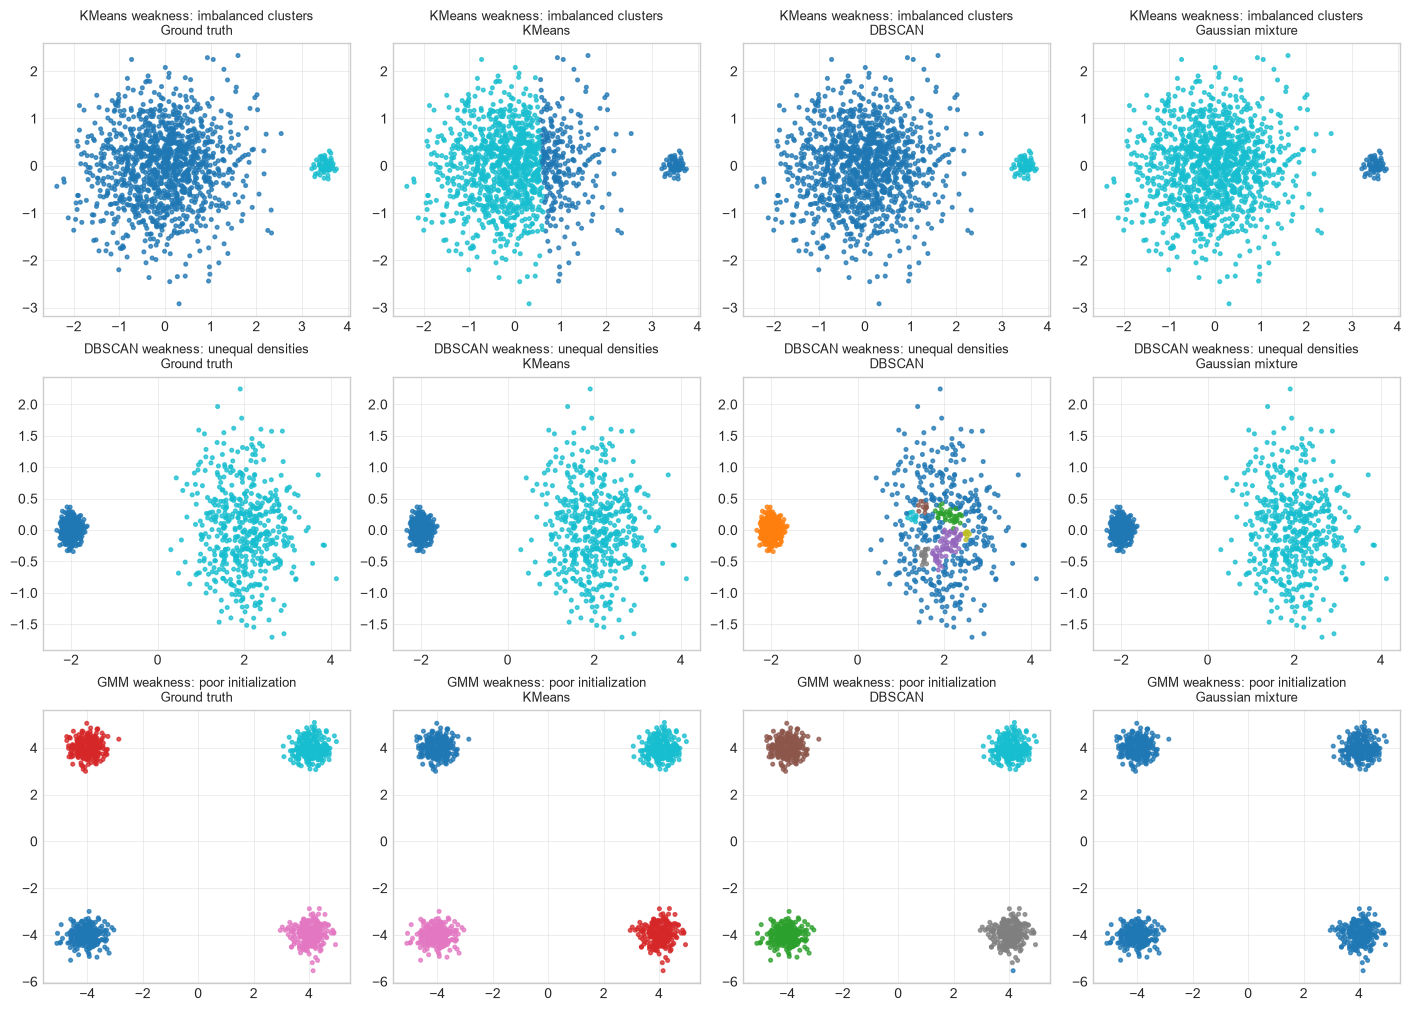

2026-08-30 17:06:11,559 | INFO | unsupervised_exercise | Robustly initialized GMM ARI: 1.000


,dataset,algorithm,ARI,seconds,clusters_found
0,KMeans weakness: imbalanced clusters,KMeans,0.188,2.5088,2
1,KMeans weakness: imbalanced clusters,DBSCAN,1.000,0.0287,2
2,KMeans weakness: imbalanced clusters,Gaussian mixture,1.000,0.3327,2
3,DBSCAN weakness: unequal densities,KMeans,1.000,0.0495,2
4,DBSCAN weakness: unequal densities,DBSCAN,0.770,0.0253,8
5,DBSCAN weakness: unequal densities,Gaussian mixture,1.000,0.0821,2
6,GMM weakness: poor initialization,KMeans,1.000,0.0514,4
7,GMM weakness: poor initialization,DBSCAN,0.999,0.0263,5
8,GMM weakness: poor initialization,Gaussian mixture,0.000,0.0067,1


In [3]:
from unsupervised_utils import (
    create_clustering_failure_cases,
    evaluate_clustering_cases,
    plot_clustering_assignments,
    validate_clustering_results,
)

clustering_cases = create_clustering_failure_cases(
    random_seed=RANDOM_SEED
)
clustering_results, clustering_assignments = evaluate_clustering_cases(
    clustering_cases=clustering_cases
)
robust_gmm_ari = validate_clustering_results(
    clustering_cases=clustering_cases,
    clustering_results=clustering_results,
    random_seed=RANDOM_SEED,
)

figure = plot_clustering_assignments(
    clustering_cases=clustering_cases,
    clustering_assignments=clustering_assignments,
)
figure.savefig(
    fname=OUTPUT_DIRECTORY / "clustering_failure_cases.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

LOGGER.info(msg=f"Robustly initialized GMM ARI: {robust_gmm_ari:.3f}")
clustering_results

**Observed weaknesses.** KMeans is pulled toward the large diffuse group and misses the small group. DBSCAN is highly sensitive to a single neighborhood radius when densities differ. GMM can collapse under a symmetric poor initialization; using multiple k-means++ starts recovers the four clusters (ARI = 1.000).

```Answer the following questions based on what you learned from the previous question:```
- ```Which method is easiest to use?```
- ```Which method is the fastest to use?```

**Answer.** KMeans is the easiest here when the number of roughly compact clusters is known. DBSCAN was fastest on these small 2D examples, but speed depends on sample size, dimension, indexing, and hyperparameters; the timing table is evidence for this run, not a universal ranking.

```We will now use K-Means to quantize image colors:```

```First load the given celebrity image from the image folder (can be found in:```
https://drive.google.com/file/d/1nUk_Q-ahhUrjmUl_sM9ovb84DybuaQCe/view?usp=sharing)

In [4]:
import cv2

In [5]:
import os

from unsupervised_init import IMAGE_DIRECTORY

os.chdir(IMAGE_DIRECTORY.parent)

In [6]:
img = cv2.imread('images/Alicia Vikander/1.jpg')[:,:,::-1]
img_array = np.array(img)

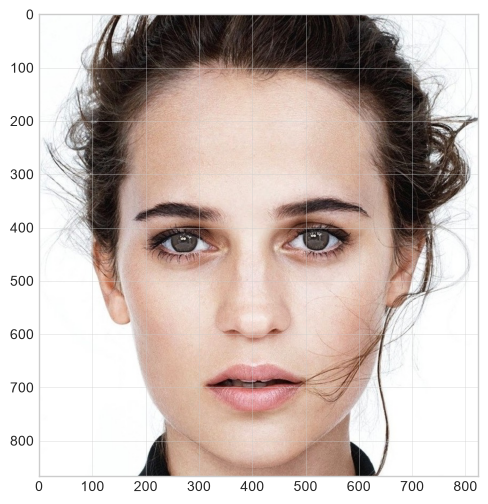

In [7]:
plt.figure(figsize=(6,6))
plt.imshow(img_array)

```Every pixel in the image is composed of three colors (Red, Green, Blue), and therefore, every pixel is a vector: (r,g,b).```
```Create a list of every color pixel in the image: (array.reshape will work)```

In [8]:
color_pixels = img_array.reshape((-1, 3)).astype(dtype=np.float32)
LOGGER.info(msg=f"Color matrix shape: {color_pixels.shape}")

2026-08-30 17:06:12,643 | INFO | unsupervised_exercise | Color matrix shape: (715275, 3)


```Train a K-Means model with k=10 on the list of colors:```

In [9]:
from sklearn.cluster import KMeans

In [10]:
color_kmeans = KMeans(
    n_clusters=10,
    n_init=3,
    max_iter=100,
    random_state=RANDOM_SEED,
)
color_cluster_labels = color_kmeans.fit_predict(X=color_pixels)
LOGGER.info(msg=f"Color-quantization inertia: {color_kmeans.inertia_:.0f}")

2026-08-30 17:06:14,047 | INFO | unsupervised_exercise | Color-quantization inertia: 142573632


```Now replace every color vector with the vector of centroid bector of it's cluster.```
```rebuild the image and plot it. How is it compared to the original?```

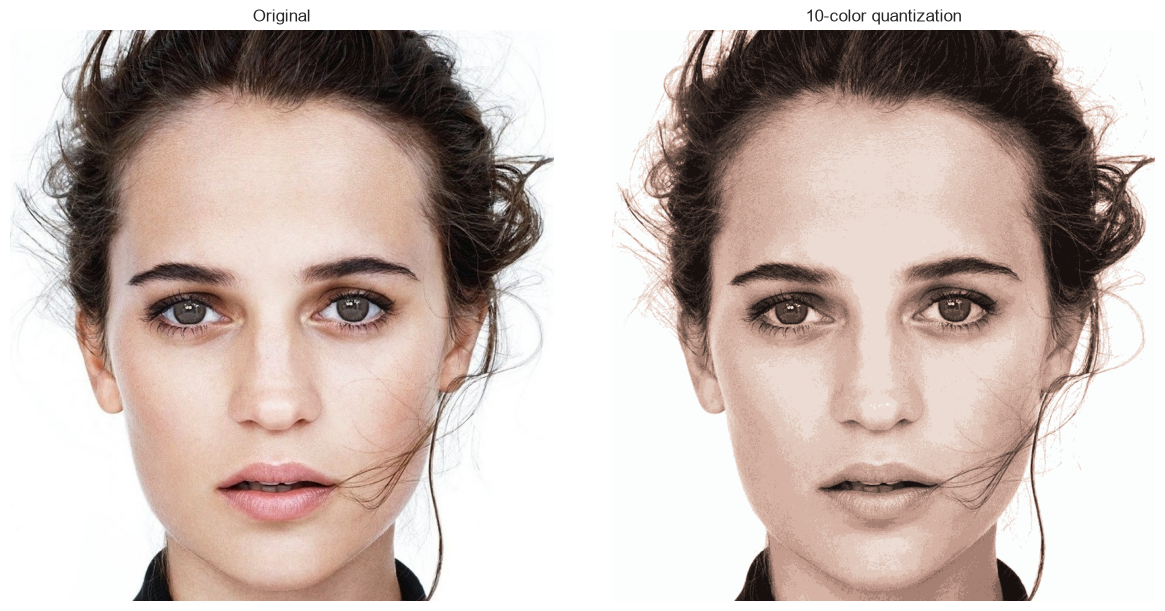

In [11]:
quantized_pixels = color_kmeans.cluster_centers_[color_cluster_labels]
quantized_image = np.clip(
    a=quantized_pixels.reshape(img_array.shape),
    a_min=0,
    a_max=255,
).astype(dtype=np.uint8)

figure, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 6),
    constrained_layout=True,
)
axes[0].imshow(X=img_array)
axes[0].set_title(label="Original")
axes[1].imshow(X=quantized_image)
axes[1].set_title(label="10-color quantization")
for current_axes in axes:
    current_axes.axis("off")
figure.savefig(
    fname=OUTPUT_DIRECTORY / "color_quantization.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

**Answer.** Ten centroids preserve the main colors and recognizable structure, but smooth gradients and fine color variation become visible bands.

```Train K-Means model with k=2,...,15, and plot the "within-cluster sum-of-squares criterion"```($R_k$)``` for all the k's.```

```(reduce the n_init if it takes too much time)```

(Explain on $R_k$ can be found in: https://scikit-learn.org/stable/modules/clustering.html#k-means)

```Can we conclude "how many clusters" are there, from the graph?```

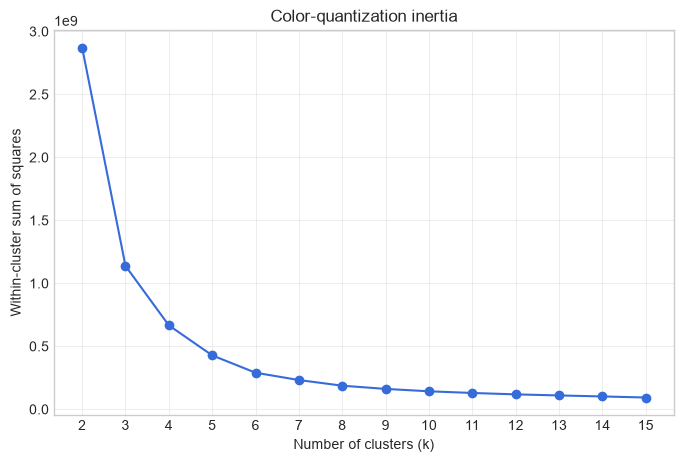

In [12]:
cluster_counts = np.arange(start=2, stop=16)
within_cluster_sums_of_squares = []

for current_cluster_count in cluster_counts:
    current_color_model = KMeans(
        n_clusters=current_cluster_count,
        n_init=1,
        max_iter=100,
        random_state=RANDOM_SEED,
    )
    current_color_model.fit(X=color_pixels)
    within_cluster_sums_of_squares.append(current_color_model.inertia_)

figure, axes = plt.subplots(figsize=(8, 5))
axes.plot(
    cluster_counts,
    within_cluster_sums_of_squares,
    marker="o",
)
axes.set(
    xlabel="Number of clusters (k)",
    ylabel="Within-cluster sum of squares",
    title="Color-quantization inertia",
    xticks=cluster_counts,
)
figure.savefig(
    fname=OUTPUT_DIRECTORY / "color_inertia_curve.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

**Answer.** Inertia must decrease as (k) grows. The curve can suggest a useful elbow, but an image has a continuous color distribution, so it does not define one objectively correct number of color clusters.

# part 2 - Dimensionality reduction

```The goal of this part is to experience with some basic features of PCA, and have a notion about the capabilities, and uses of this method.```

```We will look on facial images of 3 celebrities, and use PCA to extract facial patterns from images.```
```We then try to use those patterns to build a classifier that can distinguish the 3 celebrities.```

In [13]:
celebs = ['Alicia Vikander', 'Amy Adams', 'Andy Serkis']
# images folder in: https://drive.google.com/file/d/1nUk_Q-ahhUrjmUl_sM9ovb84DybuaQCe/view?usp=sharing

```First we load the face images:```

In [14]:
from unsupervised_utils import read_gray_image

In [15]:
face_image_paths = []
face_imgs = []
labels = []

for celebrity_index, celebrity_name in enumerate(celebs):
    current_paths = sorted(
        (IMAGE_DIRECTORY / celebrity_name).glob(pattern="*.jpg"),
        key=lambda image_path: int(image_path.stem),
    )
    if not current_paths:
        raise FileNotFoundError(
            f"No images found for {celebrity_name} in {IMAGE_DIRECTORY}"
        )
    face_image_paths.extend(current_paths)
    labels.extend([celebrity_index] * len(current_paths))
    face_imgs.extend(
        read_gray_image(path=image_path)
        for image_path in current_paths
    )

LOGGER.info(
    msg=(
        f"Loaded {len(face_imgs)} images: "
        + ", ".join(
            f"{celebrity_name}={labels.count(celebrity_index)}"
            for celebrity_index, celebrity_name in enumerate(celebs)
        )
    )
)

2026-08-30 17:06:21,879 | INFO | unsupervised_exercise | Loaded 357 images: Alicia Vikander=112, Amy Adams=119, Andy Serkis=126


```For later steps, we would like to resize all the images to have the same width x height. It is best to choose new shape that least distort the images.```

```Plot the shapes of all the images on the "width", "height" plane: (What does that remind you of?)```

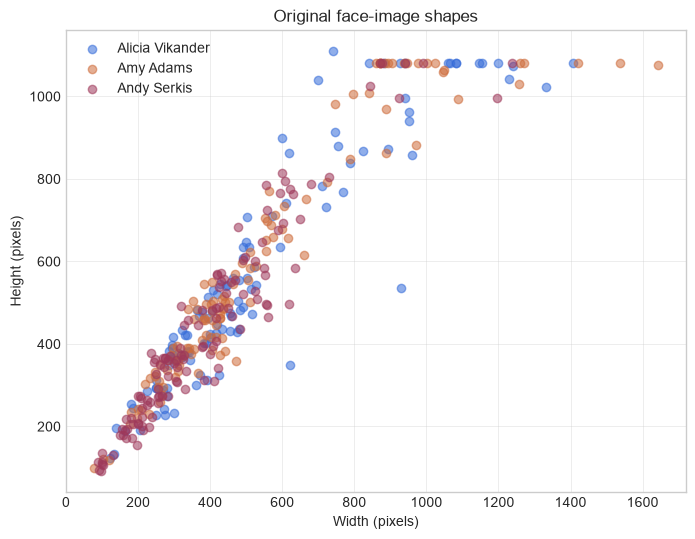

In [16]:
image_shapes = np.array(
    object=[(image.shape[1], image.shape[0]) for image in face_imgs],
    dtype=np.int32,
)

figure, axes = plt.subplots(figsize=(8, 6))
for celebrity_index, celebrity_name in enumerate(celebs):
    celebrity_mask = np.array(object=labels) == celebrity_index
    axes.scatter(
        x=image_shapes[celebrity_mask, 0],
        y=image_shapes[celebrity_mask, 1],
        alpha=0.55,
        label=celebrity_name,
    )
axes.set(
    xlabel="Width (pixels)",
    ylabel="Height (pixels)",
    title="Original face-image shapes",
)
axes.legend()

```Now on the same plot, draw the point of the "avarage shape". Is it looks like it represents the trend?```

```Resize all the face images to have the "avarage shape." ( cv2.resize will work)```

In [17]:
average_width, average_height = (
    image_shapes.mean(axis=0).round().astype(dtype=np.int32)
)
axes.scatter(
    x=[average_width],
    y=[average_height],
    marker="X",
    s=180,
    color="black",
    label="Rounded average shape",
)
axes.legend()
figure.savefig(
    fname=OUTPUT_DIRECTORY / "image_shapes.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

resized_face_imgs = [
    cv2.resize(
        src=image,
        dsize=(average_width, average_height),
        interpolation=cv2.INTER_AREA,
    )
    for image in face_imgs
]
LOGGER.info(
    msg=f"All images resized to width={average_width}, height={average_height}"
)

2026-08-30 17:06:22,391 | INFO | unsupervised_exercise | All images resized to width=485, height=531


**Answer.** The rounded mean is a reasonable common canvas near the center of the observed width-height cloud, although resizing still changes individual aspect ratios.

```Flatten all the images into vectors, and split them randomly to train and test groups (with ratio (0.7, 0.3)).```

In [18]:
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

In [19]:
flattened_images = np.stack(
    arrays=[image.reshape(-1) for image in resized_face_imgs],
    axis=0,
).astype(dtype=np.float32)
image_labels = np.array(object=labels, dtype=np.int8)

(
    images_train,
    images_test,
    labels_train,
    labels_test,
) = train_test_split(
    flattened_images,
    image_labels,
    train_size=0.70,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=image_labels,
)

LOGGER.info(
    msg=(
        f"Flattened data: {flattened_images.shape}; "
        f"train={images_train.shape}, test={images_test.shape}"
    )
)

2026-08-30 17:06:22,642 | INFO | unsupervised_exercise | Flattened data: (357, 257535); train=(249, 257535), test=(108, 257535)


```Now train a PCA model with n_components=10 on the train set. How much variance(in %) the 10 components explain? is it good compared to the dimention of the vectors?```

In [20]:
global_pca = PCA(
    n_components=10,
    svd_solver="randomized",
    random_state=RANDOM_SEED,
)
global_pca.fit(X=images_train)
explained_variance_percentage = (
    global_pca.explained_variance_ratio_.sum() * 100.0
)
LOGGER.info(
    msg=(
        f"Ten PCA components explain "
        f"{explained_variance_percentage:.2f}% of training variance "
        f"using only 10 of {images_train.shape[1]} dimensions."
    )
)

2026-08-30 17:06:36,856 | INFO | unsupervised_exercise | Ten PCA components explain 64.08% of training variance using only 10 of 257535 dimensions.


**Answer.** The logged percentage quantifies the variance retained by only ten directions instead of one coordinate per pixel. This is substantial compression, though reconstruction quality must still be judged visually.

```Take the 10 component vectors of the model, reshape them to the image shape, and plot all of them:```

It looks something like that:
![image.png](attachment:image.png)

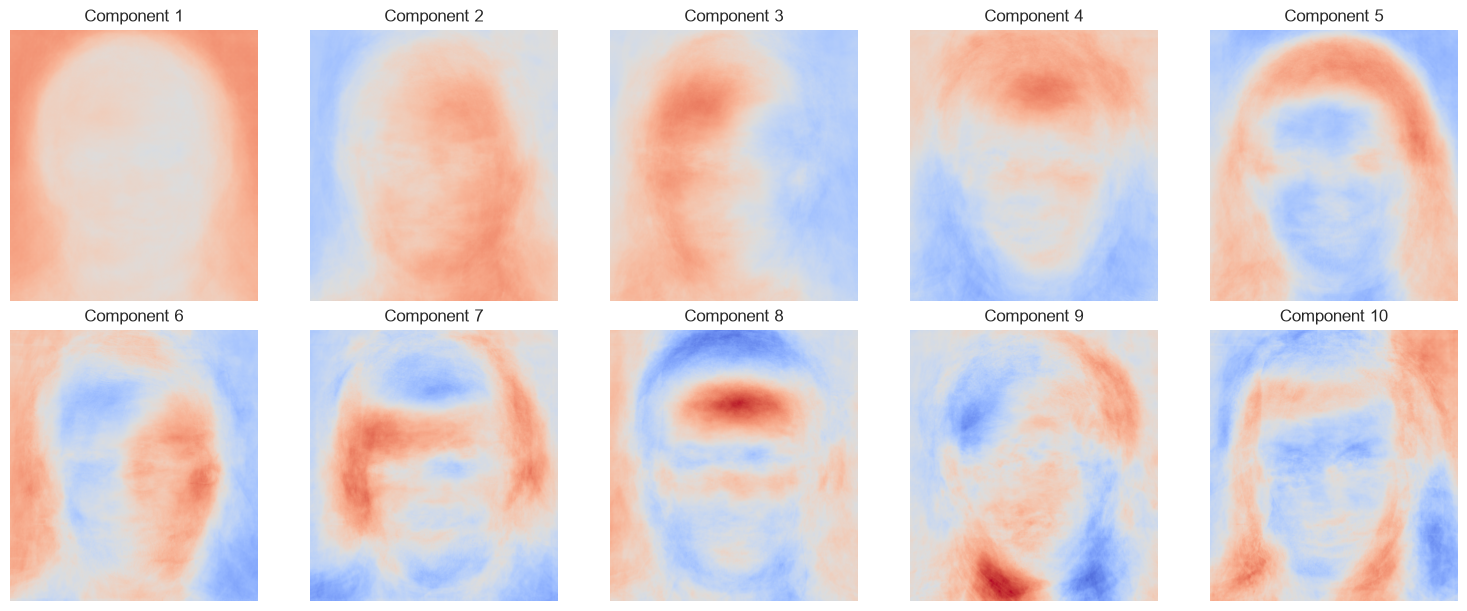

In [21]:
component_scale = np.abs(global_pca.components_).max()
figure, axes = plt.subplots(
    nrows=2,
    ncols=5,
    figsize=(15, 6),
    constrained_layout=True,
)
for component_index, current_axes in enumerate(axes.ravel()):
    current_axes.imshow(
        X=global_pca.components_[component_index].reshape(
            (average_height, average_width)
        ),
        cmap="coolwarm",
        vmin=-component_scale,
        vmax=component_scale,
    )
    current_axes.set_title(label=f"Component {component_index + 1}")
    current_axes.set_axis_off()
figure.savefig(
    fname=OUTPUT_DIRECTORY / "pca_components.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

```The "faces" that we got, can roוghly be refered to as the "face patterns" that are the most dominant in the images. can you make sense of the patterns?```

```Notice that if we transform an image to the low dimension and then inverse transform it back, we actually find the "best combination of the patterns" that reconstract out image```

**Interpretation.** These components are global contrast patterns—not literal faces. Their light and dark regions describe coordinated pixel changes caused by facial structure, pose, illumination, and alignment.

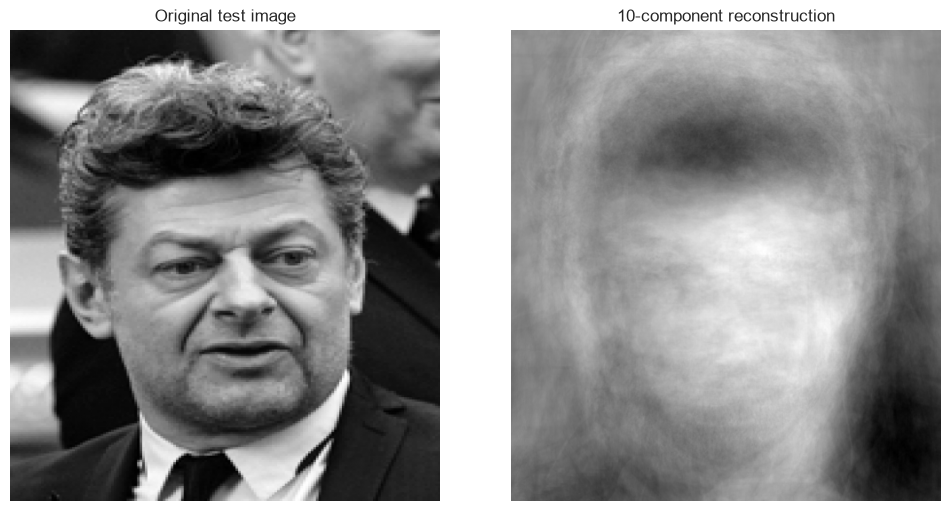

In [22]:
from unsupervised_utils import reconstruct_with_pca

example_original = images_test[:1]
example_reconstruction = reconstruct_with_pca(
    pca_model=global_pca,
    samples=example_original,
)

figure, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(10, 5),
    constrained_layout=True,
)
axes[0].imshow(
    X=example_original.reshape((average_height, average_width)),
    cmap="gray",
)
axes[0].set_title(label="Original test image")
axes[1].imshow(
    X=example_reconstruction.reshape((average_height, average_width)),
    cmap="gray",
)
axes[1].set_title(label="10-component reconstruction")
for current_axes in axes:
    current_axes.set_axis_off()
figure.savefig(
    fname=OUTPUT_DIRECTORY / "pca_reconstruction.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

```Now make a PCA model with n_components=10 for the images of every celebrity in the train set (pca_1, pca_2, pca_3). And Then:```

- ```Take all the vectors from the test set.```
- ```Transform them to the low dimension.```
- ```Inverse transform them back to original dimension.```
- ```Compute "mean square error" (MSE) between the original vectors to the reconstructed version of themselves.```
- ```For every vector, mark the PCA model that gave the smallest MSE. (as prediction)```
- ```Print the "confusion matrix" of the prediction.``` (https://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html)

In [23]:
from sklearn.metrics import confusion_matrix

2026-08-30 17:06:40,968 | INFO | unsupervised_exercise | Fitted one 10-component PCA model for each celebrity


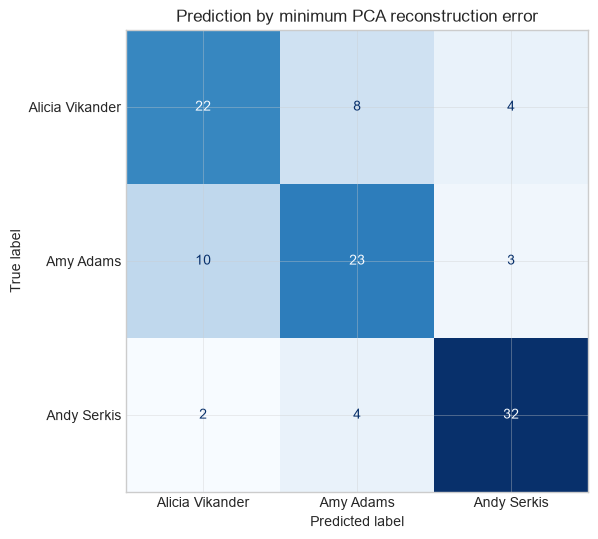

2026-08-30 17:06:41,721 | INFO | unsupervised_exercise | 10-component PCA classifier accuracy: 0.713


array([[22,  8,  4],
       [10, 23,  3],
       [ 2,  4, 32]])

In [24]:
from unsupervised_utils import (
    fit_class_pca_models,
    predict_by_reconstruction_error,
)

from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score

celebrity_pca_models = fit_class_pca_models(
    training_samples=images_train,
    training_labels=labels_train,
    class_count=len(celebs),
    component_count=10,
    random_seed=RANDOM_SEED,
)
LOGGER.info(
    msg="Fitted one 10-component PCA model for each celebrity"
)

celebrity_predictions, reconstruction_error_matrix = (
    predict_by_reconstruction_error(
        pca_models=celebrity_pca_models,
        samples=images_test,
    )
)
celebrity_confusion_matrix = confusion_matrix(
    y_true=labels_test,
    y_pred=celebrity_predictions,
    labels=np.arange(start=0, stop=len(celebs)),
)
celebrity_accuracy = accuracy_score(
    y_true=labels_test,
    y_pred=celebrity_predictions,
)

figure, axes = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(
    confusion_matrix=celebrity_confusion_matrix,
    display_labels=celebs,
).plot(
    include_values=True,
    cmap="Blues",
    ax=axes,
    colorbar=False,
    values_format="d",
)
axes.set_title(label="Prediction by minimum PCA reconstruction error")
figure.savefig(
    fname=OUTPUT_DIRECTORY / "pca_confusion_matrix.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

LOGGER.info(msg=f"10-component PCA classifier accuracy: {celebrity_accuracy:.3f}")
celebrity_confusion_matrix

```Is it work well? If yes, try to explain why.```

In [25]:
classification_summary = (
    "Each class-specific PCA learns a low-dimensional appearance subspace. "
    "A test image is assigned to the subspace that reconstructs it with the "
    "smallest mean squared error; performance is limited by pose, lighting, "
    "alignment, and overlap between the three subspaces."
)
LOGGER.info(msg=classification_summary)

2026-08-30 17:06:41,822 | INFO | unsupervised_exercise | Each class-specific PCA learns a low-dimensional appearance subspace. A test image is assigned to the subspace that reconstructs it with the smallest mean squared error; performance is limited by pose, lighting, alignment, and overlap between the three subspaces.


## Bonus (5 pts)

```Perform the prediction process with PCA models with n_components=[1,10,20,30,40,50,60,70].```

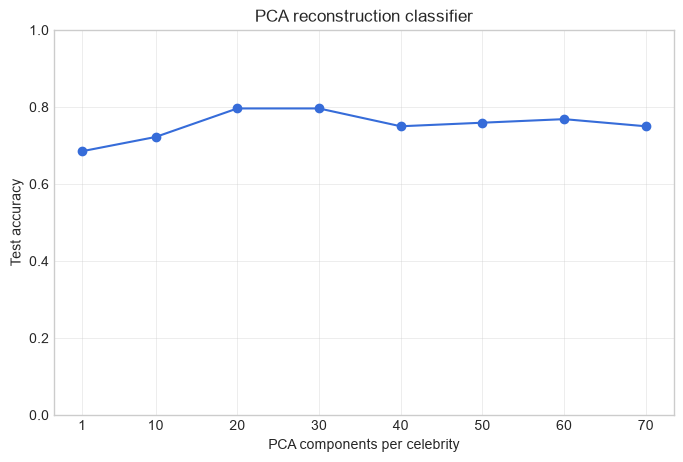

2026-08-30 17:06:45,130 | INFO | unsupervised_exercise | Best bonus accuracy: 0.796 at 20 components


,n_components,accuracy
0,1,0.685185
1,10,0.722222
2,20,0.796296
3,30,0.796296
4,40,0.750000
5,50,0.759259
6,60,0.768519
7,70,0.750000


In [26]:
from unsupervised_utils import evaluate_pca_component_counts

component_counts = np.array(
    object=[1, 10, 20, 30, 40, 50, 60, 70],
    dtype=np.int32,
)
maximum_component_pca_models, bonus_results = (
    evaluate_pca_component_counts(
        training_samples=images_train,
        training_labels=labels_train,
        test_samples=images_test,
        test_labels=labels_test,
        component_counts=component_counts,
        class_count=len(celebs),
        random_seed=RANDOM_SEED,
    )
)

figure, axes = plt.subplots(figsize=(8, 5))
axes.plot(
    bonus_results["n_components"],
    bonus_results["accuracy"],
    marker="o",
)
axes.set(
    xlabel="PCA components per celebrity",
    ylabel="Test accuracy",
    title="PCA reconstruction classifier",
    xticks=component_counts,
    ylim=(0.0, 1.0),
)
figure.savefig(
    fname=OUTPUT_DIRECTORY / "pca_component_accuracy.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

best_bonus_row = bonus_results.loc[
    bonus_results["accuracy"].idxmax()
]
LOGGER.info(
    msg=(
        f"Best bonus accuracy: {best_bonus_row['accuracy']:.3f} "
        f"at {best_bonus_row['n_components']:.0f} components"
    )
)
bonus_results

```Plot the accuracy of the models. what is the trend of the performance when n_components increases? Is it what you expected? try to explain.```

**Answer.** More components reduce reconstruction error for every class, but classification accuracy need not increase monotonically: later components can model lighting, pose, and individual-image noise shared across classes. The plotted test accuracies show where useful identity structure saturates for this split.

In [27]:
LOGGER.info(
    msg=f"Timestamped output files: {OUTPUT_DIRECTORY.resolve()}"
)

2026-08-30 17:06:45,359 | INFO | unsupervised_exercise | Timestamped output files: C:\Users\asherk\PycharmProjects\DS_Training\D - ML\unsupervised\exercise\outputs\clustering_exercise_20260830_170605
